In [2]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import getpass
import subprocess
import time
import importlib
from shutil import copy2

%load_ext autoreload
%autoreload 2

!nvcc --version

### Path to this cloned GitHub repo:
SCRIPT_DIR = os.path.dirname("/home/feng/Feng/hg/heme_binder_diffusion_ff/")  # edit this to the GitHub repo path. Throws an error by default.
assert os.path.exists(SCRIPT_DIR)
sys.path.append(SCRIPT_DIR+"/scripts/utils")
print(SCRIPT_DIR+"/scripts/utils")
print(os.listdir(SCRIPT_DIR+"/scripts/utils"))
#sys.path.insert(0, SCRIPT_DIR+"/scripts/utils")
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
/home/feng/Feng/hg/heme_binder_diffusion_ff/scripts/utils
['place_ligand_after_af2.py', 'pssm_tools.py', '__pycache__', 'utils.py', 'DAlphaBall.gcc', 'design_utils.py', 'scoring_utils.py', 'no_ligand_repack.py', 'analyze_af2.py']


# De novo heme binding protein design pipeline using RFdiffusionAA
#### And other ligand binders too, I guess
Indrek Kalvet, PhD (Institute for Protein Design, University of Washington), ikalvet@uw.edu

As implemented in the publication "<i>Generalized Biomolecular Modeling and Design with RoseTTAFold All-Atom"

Link:

This notebook illustrates the design of heme-binding proteins, starting from minimal information (heme + substrate + CYS motif). It should work with minor modifications also for any other ligand.

The pipeline consists of 7 steps:<br>

    0) The protein backbones are generated with RFdiffusionAA
    1) Sequence is designed with proteinMPNN (without the ligand)
    2) Structures are predicted with AlphaFold2
    3) Ligand binding site is designed with LigandMPNN/FastRelax, or Rosetta FastDesign
    4) Sequences surrounding the ligand pocket are diversified with LigandMPNN
    5) Final designed sequences are predicted with AlphaFold2
    6) Alphafold2-predicted models are relaxed with the ligand and analyzed


## Paths of important Python scripts and programs

#### RFdiffusionAA:
Download RFdiffusionAA from here: https://github.com/baker-laboratory/rf_diffusion_all_atom

#### RFjoint inpainting (proteininpainting)
(Optional) Download RFjoint Inpainting here: https://github.com/RosettaCommons/RFDesign

Inpainting is used to further resample/diversify diffusion outputs, and it may also increase AF2 success rates.
<br>

#### AlphaFold2 and LigandMPNN
Other dependencies (ligandMPNN and AlphaFold2) are downloaded as submodules with this GitHub repository.

<br>
<br>
<i>After these evironments are set up and repositories are downloaded please provide paths to the inference scripts in the cell below:</i>

<br>
<br>

#### Python or Apptainer image
Please define in the cell below any Python executables or Apptainer image paths that are able to run the different scripts.<br>

This pipeline is tested to run based on two different Conda environments: `diffusion` and `mlfold`.<br>
Both of these can be set up based on the yml files provided by this repository.<br>
`mlfold` is used for AlphaFold2, and `diffusion` is used for everything else.

<br>

Alternatively, if your system is using Apptainers, you can set them up based on the same yml files, or do it separately. For RFdiffusionAA you can download this Apptainer image:
http://files.ipd.uw.edu/pub/RF-All-Atom/containers/rf_se3_diffusion.sif

If you are setting the environments or containers up without the provided YML files, then the minimum requirements for the different types are:<br>
`af2` Python needs to include jax=0.4.25 and jaxlib=0.4.23<br>
`proteinMPNN` Python needs to include pytorch and prody<br>
`general` Python needs to include pytorch, pyrosetta, prody<br>



In [3]:
diffusion_script = "/home/feng/Feng/hg/rf_diffusion_all_atom/run_inference.py"  # edit this
inpaint_script = "/home/feng/Feng/hg/RFDesign/inpainting/inpaint.py"  # edit this if needed
proteinMPNN_script = f"{SCRIPT_DIR}/lib/LigandMPNN/run.py"  # from submodule
AF2_script = f"{SCRIPT_DIR}/scripts/af2/af2.py"  # from submodule

#added by Feng, so to check wether they are exist, in case.
if not os.path.exists(diffusion_script):
    print("ERROR: diffusion_script does not exists!!!")
    
assert os.path.exists(proteinMPNN_script)

assert os.path.exists(AF2_script)


### Python and/or Apptainer executables needed for running the jobs
### Please provide paths to executables that are able to run the different tasks.
### They can all be the same if you have an environment with all of the ncessary Python modules in one

# If your added Apptainer does not execute scripts directly,
# try adding 'apptainer run' or 'apptainer run --nv' (for GPU) in front of the command

CONDAPATH = "/home/feng/miniconda3"   # edit this depending on where your Conda environments live
PYTHON = {"diffusion": f"{CONDAPATH}/envs/diffusion/bin/python",
          "af2": f"{CONDAPATH}/envs/mlfold/bin/python",
          "proteinMPNN": f"{CONDAPATH}/envs/ligandmpnn_env/bin/python",
          "general": f"{CONDAPATH}/envs/diffusion/bin/python"}

## Project description and paths

In [4]:
username = getpass.getuser()  # your username on the running system
EMAIL = f"{username}@bu.edu"  # edit based on your organization. For Slurm job notifications.

PROJECT = "example_Heme_diffusion"

print("Username:", username)
print(f"Email:{EMAIL}")
print(f"Project:{PROJECT}")


### Path where the jobs will be run and outputs dumped
WDIR = "/mnt/data/Feng/heme_pipeline/protein_design/project1"

if not os.path.exists(WDIR):
    os.makedirs(WDIR, exist_ok=True)

print(f"Working directory: {WDIR}")

USE_GPU_for_AF2 = True


Username: feng
Email:feng@bu.edu
Project:example_Heme_diffusion
Working directory: /mnt/data/Feng/heme_pipeline/protein_design/project1


In [5]:
# Ligand information
params = [f"{SCRIPT_DIR}/theozyme/HBA/HBA.params"]  # Rosetta params file(s)
print(params)

for p in params:
    if not os.path.exists(p):
        print("Error: missing param file!!")
    else :
        print(f"Checking param file \"{os.path.basename(p)}\"....yes, file found!!!")
        
LIGAND = "HBA"

['/home/feng/Feng/hg/heme_binder_diffusion_ff/theozyme/HBA/HBA.params']
Checking param file "HBA.params"....yes, file found!!!


## 0: Setting up diffusion run

In [6]:
# Using example PDB file with ligand HBA and protein 7o2g backbone.
## Note: the repository also contains additional HBA conformers with 7o2g and P450 motifs
## in the same directory as a ZIP file.

diffusion_inputs = glob.glob(f"{SCRIPT_DIR}/input/*.pdb")
print(f"Found {len(diffusion_inputs)} PDB files")
print(diffusion_inputs)

Found 1 PDB files
['/home/feng/Feng/hg/heme_binder_diffusion_ff/input/7o2g_HBA.pdb']


In [7]:
## Setting up general settings for diffusion

DIFFUSION_DIR = f"{WDIR}/1_diffusion_50"
if not os.path.exists(DIFFUSION_DIR):
    os.makedirs(DIFFUSION_DIR, exist_ok=False)

os.chdir(DIFFUSION_DIR)

N_designs = 50
T_steps = 100

## Edit this config based on motif residues, etc...
config = f"""
defaults:
  - aa

diffuser:
  T: {T_steps}

inference:
  num_designs: {N_designs}
  model_runner: NRBStyleSelfCond
  ligand: '{LIGAND}'

model:
  freeze_track_motif: True

contigmap:
  contigs: ["30-110,A15-15,30-110"]
  inpaint_str: null
  length: "100-140"

potentials:
  guiding_potentials: ["type:ligand_ncontacts,weight:1"] 
  guide_scale: 2
  guide_decay: cubic
"""

estimated_time = 3.5 * T_steps * N_designs  # assuming 3.5 seconds per timestep on A4000 GPU

print(f"Estimated time to produce {N_designs} designs = {estimated_time/60:.0f} minutes")
with open("config.yaml", "w") as file:
    file.write(config)
print(f"Wrote config file to {os.path.realpath('config.yaml')}")

Estimated time to produce 50 designs = 292 minutes
Wrote config file to /mnt/data/Feng/heme_pipeline/protein_design/project1/1_diffusion_50/config.yaml


In [8]:
## Setting up diffusion commands based on the input PDB file(s)
## Diffusion jobs are run in separate directories for each input PDB

commands_diffusion = []
cmds_filename = "commands_diffusion"
diffusion_rundirs = []
print(os.getcwd())

submit_commands={}  # added by Feng to remember the command to submit to run local with subprocess

with open(cmds_filename, "w") as file:
    for p in diffusion_inputs:
        pdbname = os.path.basename(p).replace(".pdb", "")
        os.makedirs(pdbname, exist_ok=True)
        cmd_submit_temp=[f"{PYTHON['diffusion']}", f"{diffusion_script}",f"--config-dir=../",\
              f"--config-name=config.yaml",f"inference.input_pdb={p}",\
              f"inference.output_prefix='./out/{pdbname}_dif'"]#,f" > output.log"] 
        
        cmd = f"cd {pdbname} ; {PYTHON['diffusion']} {diffusion_script} --config-dir=../ "\
              f"--config-name=config.yaml inference.input_pdb={p} "\
              f"inference.output_prefix='./out/{pdbname}_dif' > output.log ; cd ..\n"
        commands_diffusion.append(cmd)
        diffusion_rundirs.append(pdbname)
        file.write(cmd)
        submit_commands.update({pdbname:cmd_submit_temp})

print(f"An example diffusion command that was generated:\n   {cmd}")

print(f"showing the command dictionary:{submit_commands}")


/mnt/data/Feng/heme_pipeline/protein_design/project1/1_diffusion_50
An example diffusion command that was generated:
   cd 7o2g_HBA ; /home/feng/miniconda3/envs/diffusion/bin/python /home/feng/Feng/hg/rf_diffusion_all_atom/run_inference.py --config-dir=../ --config-name=config.yaml inference.input_pdb=/home/feng/Feng/hg/heme_binder_diffusion_ff/input/7o2g_HBA.pdb inference.output_prefix='./out/7o2g_HBA_dif' > output.log ; cd ..

showing the command dictionary:{'7o2g_HBA': ['/home/feng/miniconda3/envs/diffusion/bin/python', '/home/feng/Feng/hg/rf_diffusion_all_atom/run_inference.py', '--config-dir=../', '--config-name=config.yaml', 'inference.input_pdb=/home/feng/Feng/hg/heme_binder_diffusion_ff/input/7o2g_HBA.pdb', "inference.output_prefix='./out/7o2g_HBA_dif'"]}


**Feng notes:** Very interestingly, we need to revise the script, "run_inference.py", to move "import numpy" to the beginnng of the module. Otherwise we will see error like:

" b'Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp.so.1 library.\n\tTry to import numpy first or set the threading layer accordingly. Set MKL_SERVICE_FORCE_INTEL to force it.\n' "

Google gemini is saying we need to move numpy to the beginning, so 

"In some cases, importing numpy before other libraries that might trigger the MKL service can help resolve the conflict by ensuring MKL is initialized correctly."

But such kind of error won't show if we simply run the script at the command line directly.


Also need to change the file in rf_diffusion_aa folder, "/home/Feng/hg/rf_diffusion_all_atom/config/inference/aa.yaml". We need to add the absolute directory to the weight/parameter file, otherwise the script can not find the model paramter file.


In [9]:

## Creating a Slurm submit script
## adjust time depending on number of designs and available hardware
submit_script = "submit_diffusion.sh"
utils.create_slurm_submit_script(filename=submit_script, name="diffusion_example", gpu=True, gres="gpu:a4000:1",
                                 mem="8g", N_cores=2, time="1:00:00", email=EMAIL,
                                 array=len(commands_diffusion), array_commandfile=cmds_filename)

print(f"Writing diffusion submission script to {submit_script}")
print(f"{len(commands_diffusion)} diffusion jobs to run\n\n")

print("Start running the command(s).....")

for pdbname, cmd in submit_commands.items():
    if not os.path.exists(DIFFUSION_DIR+"/.done"):
        #set the working directory
        os.chdir(DIFFUSION_DIR+"/"+pdbname)
        print(f"working directory:{os.getcwd()}\n\n")
        print(f"command to run:{cmd}\n\n")
        
        p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        (output, err) = p.communicate()
        #p.wait()
        #print("**output:", output)
        with open("output.log", "w") as file_log:
            file_log.write(output)
        print("\tshowing error messages:", err)
        os.chdir("..")

        print(f"\n\nGo back to {os.getcwd()}")
    

Writing diffusion submission script to submit_diffusion.sh
1 diffusion jobs to run


Start running the command(s).....


In [10]:
print(output)


NameError: name 'output' is not defined

In [11]:
## If you're done with diffusion and happy with the outputs then mark it as done
#DIFFUSION_DIR = DIFFUSION_DIR #f"{WDIR}/0_diffusion" <---- don't need to reset it again
os.chdir(DIFFUSION_DIR)

if not os.path.exists(DIFFUSION_DIR+"/.done"):
    with open(f"{DIFFUSION_DIR}/.done", "w") as file:
        file.write(f"Run user: {username}\n")


### Analyzing diffusion outputs
The purpose of this step is to identify diffused backbones that meet certain quality criteria. These scaffolds should be relatively globular (measured by radius of gyration (rog), and longest helix). They should not have clashes between the ligand and the backbone, the ligand should not be too exposed (measured by relative SASA). The termini should not be too close to the ligand (term_mindist), and the backbone should not be too loopy. In the example below we are also looking for backbones that leave some part of the ligand more exposed.

In [12]:
### Analyzing diffusion outputs for clashes, ligand burial and scaffold quality
## If it's running too slowly consider increasing --nproc

print("Start with the script.............")

analysis_script = f"{SCRIPT_DIR}/scripts/diffusion_analysis/process_diffusion_outputs.py"

print(f"name: {analysis_script}\n\n")

#
print("enumerate the output directories..............\n\n")
print(f" diffusion_rundirs:{diffusion_rundirs} \n")
print(f" DIFFUSION_DIR:{DIFFUSION_DIR} \n")

diffusion_outputs = []
for d in diffusion_rundirs:
    diffusion_outputs += glob.glob(f"{d}/out/*.pdb")

print(f" diffusion output :{diffusion_outputs}")
print("set up the arguents..........\n\n")

# By default I don't use the --analyze flag. As a result the backbones are filtered as the script runs.
# You can set --analyze to True to calculate all scores for all backbones.
# This will slow the analysis down, but you can then filter the backbones separately afterwards.
dif_analysis_cmd_dict = {"--pdb": " ".join(diffusion_outputs),
                        "--ref": f"{SCRIPT_DIR}/input/*.pdb",
                        "--params": " ".join(params),
                        "--term_limit": "15.0",
                        "--SASA_limit": "0.3",  # Highest allowed relative SASA of ligand
                        "--loop_limit": "0.4",  # Fraction of backbone that can be loopy
                        "--ref_catres": "A15",  # Position of CYS in diffusion input
                        "--rethread": True,
                        "--fix": True,
                        "--exclude_clash_atoms": "O1 O2 O3 O4 C5 C10",  # Ligand atoms excluded from clashchecking because they are flexible
                        "--ligand_exposed_atoms": "C45 C46 C47",  # Ligand atoms that need to be more exposed
                        "--exposed_atom_SASA": "10.0",  # minimum absolute SASA for exposed ligand atoms
                        "--longest_helix": "30",
                        "--rog": "30.0",
                        "--partial": None,
                        "--outdir": None,
                        "--traj": "5/30",  # Also random 5 models are taken from the last 30 steps of the diffusion trajectory
                        "--trb": None,
                        "--analyze": False,
                        "--nproc": "1"}


print("\n\n Start building the command string........\n")

analysis_command = f"{PYTHON['general']} {analysis_script}"
for k, val in dif_analysis_cmd_dict.items():
    if val is not None:
        if isinstance(val, list):
            analysis_command += f" {k}"
            analysis_command += " " + " ".join(val)
        elif isinstance(val, bool):
            if val == True:
                analysis_command += f" {k}"
        else:
            analysis_command += f" {k} {val}"
        print(k, val)

#show the analysis command
print(f"\n\nThe analysis command :\n{analysis_command}")

if len(diffusion_outputs) < 550:  #was originally 100
    ## Analyzing locally
    p = subprocess.Popen(analysis_command, shell=True, text=True)
    (output, err) = p.communicate()
else:
    ## Too many structures to analyze.
    ## Running the analysis as a SLURM job.
    submit_script = "submit_diffusion_analysis.sh"
    utils.create_slurm_submit_script(filename=submit_script, name="diffusion_analysis",
                                     mem="8g", N_cores=dif_analysis_cmd_dict["--nproc"], time="0:20:00", email=EMAIL,
                                     command=analysis_command, outfile_name="output_analysis")

diffused_backbones_good = glob.glob(f"{DIFFUSION_DIR}/filtered_structures/*.pdb")

dif_analysis_df = pd.read_csv(f"{DIFFUSION_DIR}/diffusion_analysis.sc", header=0, sep="\\s+")

Start with the script.............
name: /home/feng/Feng/hg/heme_binder_diffusion_ff/scripts/diffusion_analysis/process_diffusion_outputs.py


enumerate the output directories..............


 diffusion_rundirs:['7o2g_HBA'] 

 DIFFUSION_DIR:/mnt/data/Feng/heme_pipeline/protein_design/project1/1_diffusion_50 

 diffusion output :['7o2g_HBA/out/7o2g_HBA_dif_33.pdb', '7o2g_HBA/out/7o2g_HBA_dif_36.pdb', '7o2g_HBA/out/7o2g_HBA_dif_11.pdb', '7o2g_HBA/out/7o2g_HBA_dif_29.pdb', '7o2g_HBA/out/7o2g_HBA_dif_16.pdb', '7o2g_HBA/out/7o2g_HBA_dif_24.pdb', '7o2g_HBA/out/7o2g_HBA_dif_5.pdb', '7o2g_HBA/out/7o2g_HBA_dif_47.pdb', '7o2g_HBA/out/7o2g_HBA_dif_23.pdb', '7o2g_HBA/out/7o2g_HBA_dif_49.pdb', '7o2g_HBA/out/7o2g_HBA_dif_1.pdb', '7o2g_HBA/out/7o2g_HBA_dif_32.pdb', '7o2g_HBA/out/7o2g_HBA_dif_26.pdb', '7o2g_HBA/out/7o2g_HBA_dif_17.pdb', '7o2g_HBA/out/7o2g_HBA_dif_4.pdb', '7o2g_HBA/out/7o2g_HBA_dif_31.pdb', '7o2g_HBA/out/7o2g_HBA_dif_35.pdb', '7o2g_HBA/out/7o2g_HBA_dif_12.pdb', '7o2g_HBA/out/7o2g_HBA_d

/home/feng/miniconda3/envs/diffusion/lib/python3.9/site-packages/pyrosetta/distributed/utility/pickle.py:49: UserWarning: __cereal_getstate__ without 'blosc' installation. Archive size will be prohibitively large. Install (pip) `blosc` and/or (conda) `python-blosc`.
  warnings.warn(
/home/feng/miniconda3/envs/diffusion/lib/python3.9/site-packages/pyrosetta/distributed/utility/pickle.py:49: UserWarning: __cereal_getstate__ without 'blosc' installation. Archive size will be prohibitively large. Install (pip) `blosc` and/or (conda) `python-blosc`.
  warnings.warn(


7o2g_HBA/out/7o2g_HBA_dif_33.pdb: fixing CYS51 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_33.pdb: ligand too exposed, L_SASA = 0.500
7o2g_HBA/out/7o2g_HBA_dif_33_traj1.pdb: fixing CYS51 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_33_traj1.pdb: ligand too exposed, L_SASA = 0.488
7o2g_HBA/out/7o2g_HBA_dif_33_traj2.pdb: fixing CYS51 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_33_traj2.pdb: ligand too exposed, L_SASA = 0.461
7o2g_HBA/out/7o2g_HBA_dif_33_traj3.pdb: fixing CYS51 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_33_traj3.pdb: ligand too exposed, L_SASA = 0.439
7o2g_HBA/out/7o2g_HBA_dif_33_traj4.pdb: fixing CYS51 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_33_traj4.pdb: ligand too exposed, L_SASA = 0.416
7o2g_HBA/out/7o2g_HBA_dif_36.pdb: terminus too close to ligand: 14.61
7o2g_HBA/out/7o2g_HBA_dif_36_traj1.pdb: terminus too close to ligand: 14.84
7o2g_HBA/out/7o2g_HBA_dif_36_traj2.pdb: fixing CYS34 with reference CYS15
7o2g_HBA/out/7o2g_HBA_dif_36_traj3.pdb: terminu

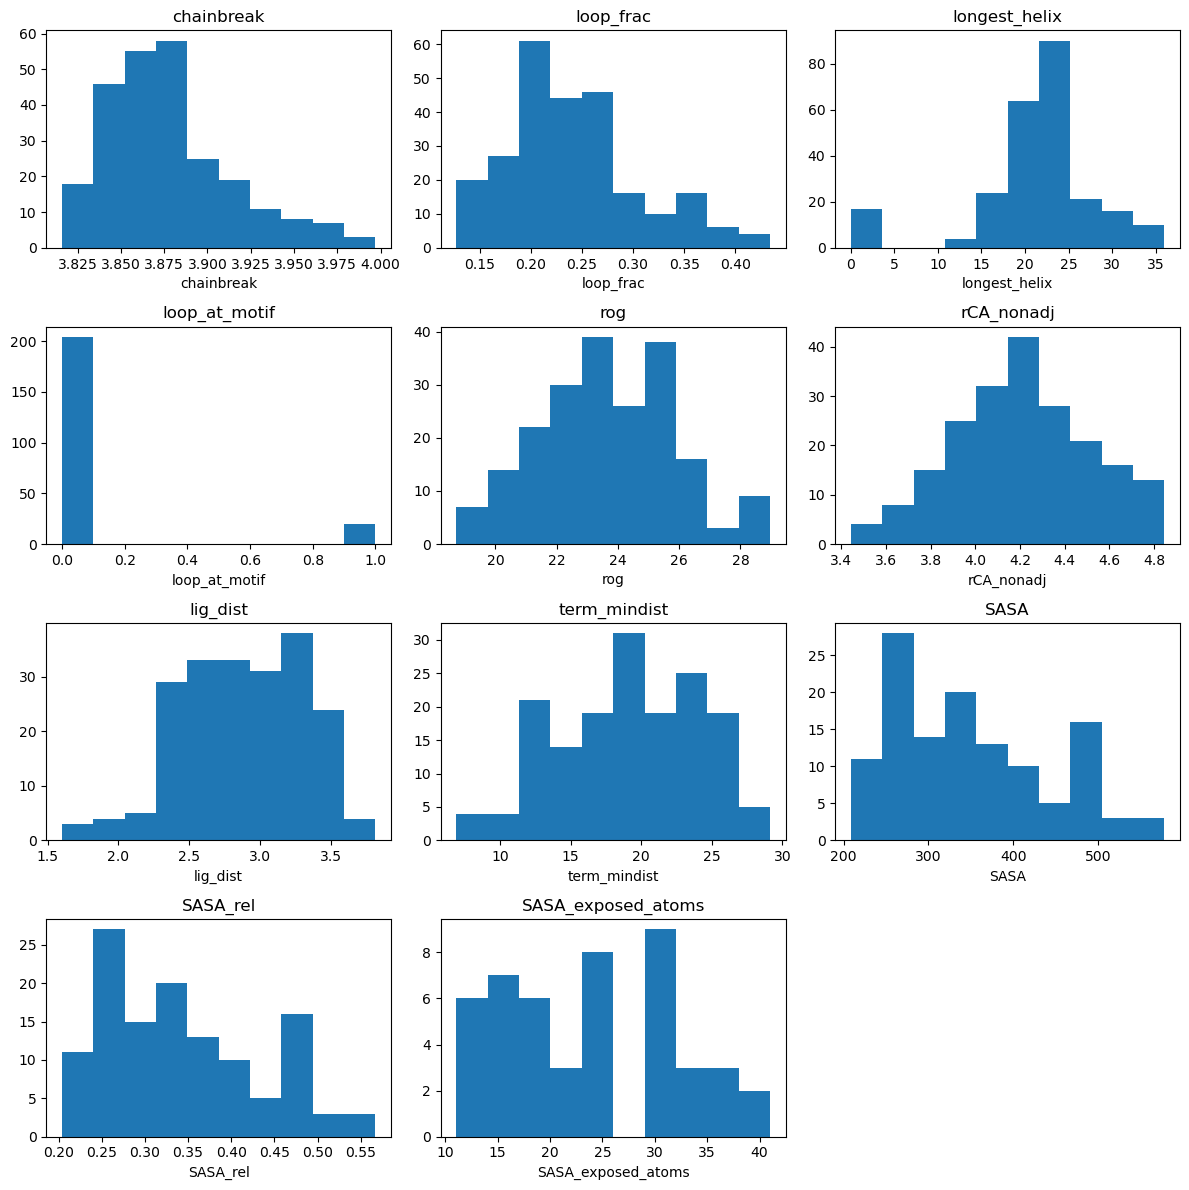

In [13]:
## Visualizing the distributions of diffusion analysis metrics
## Plotting design scores
plt.figure(figsize=(12, 12))
for i,k in enumerate(dif_analysis_df.keys()):
    if k in ["description"]:
        continue
    plt.subplot(4, 3, i+1)
    plt.hist(dif_analysis_df[k])
    plt.title(k)
    plt.xlabel(k)
plt.tight_layout()
plt.show()

It is highly advised that you manually inspect the filtered diffusion outputs before continuing with the pipeline.
While the filters attempt to pick out the most offending designs then nothing beats your own intuition and judgement.

If you would like to perform RFjoint Inpainting on the diffusion outputs, please go to the [inpainting section](#inpainting)

## 
## --------------------------------------------------------------------------------------------------------------------
<a id='inpainting'></a>

## RFjoint Inpainting diversification of diffusion outputs
This part of the pipeline branches off right after diffusion.

The purpose of inpainting diversification is to resample the loop regions of diffused backbones. Any region that is close to the ligand will not be touched because inpainting model does not see the ligand. Resampling is done with variable sequence length.

For some reason the AF2 success rates may go significantly up when performing inpainting on diffused backbones.


In [14]:
### Identifying loop regions in diffused backbones and setting up input JSON files for inpainting
assert os.path.exists(f"{DIFFUSION_DIR}/filtered_structures"), "No diffused backbones to run inpainting on"
INPAINT_DIR = f"{WDIR}/inpainting/0_inpainting"
os.makedirs(INPAINT_DIR, exist_ok=True)
os.chdir(INPAINT_DIR)


inpaint_inputs_per_job = 2  # How many structures will go into each arrayed job
inpaint_catalytic_residues = "A15"  # Catalytic residues that were used as motif during diffusion, space-separated string

inpaint_setup_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/diffusion_analysis/setup_inpaint_from_diffusion.py "\
               f"--group {inpaint_inputs_per_job} --var --design_full --params {' '.join(params)} "\
               f"--ref_catres {inpaint_catalytic_residues} "\
               f"--pdb {' '.join(glob.glob(f'{DIFFUSION_DIR}/filtered_structures/*.pdb'))}"

p = subprocess.Popen(inpaint_setup_cmd, shell=True)
(output, err) = p.communicate()


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│              See LICENSE.md or email license@uw.edu for details              │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2024 [Rosetta PyRosetta4.conda.linux.cxx11thread.serialization.CentOS.python39.Release 2024.10+release.2c36cbc7108d85646ca5b8ddc89c29ac1ccde88e 2024-03-01T16:53:36] retrieved from: http://www.pyrosetta.org
7o2g_HBA_dif_38_traj1.pdb LLLHHHHHHHHHHHHHHHHHHHHLLLHHHHHHHHHHHHHLLLHHHHHHHHHHHHHHHHHLLLLLLLHHHHHHHHHHHHLLLLLLHHHHHHHHHLLHHHHHHHHHHHHH

In [15]:
### Setting up inpainting run commands
assert os.path.exists(f"{DIFFUSION_DIR}/filtered_structures"), "No diffused backbones to run inpainting on"

commands_inpaint = []
cmds_filename = "commands_inpaint"
cmds_logfile=[]
with open(cmds_filename, "w") as file:
    for jsn in glob.glob(f"{INPAINT_DIR}/*.json"):
        commands_inpaint.append([f"{PYTHON['diffusion']}",f"{inpaint_script}",
                             f"--input_json={jsn}"]) 
        cmds_logfile.append( f"{jsn.replace('.json', '.log')}")
        #file.write(commands_inpaint[-1])

print("Example inpainting command:")
print(commands_inpaint[-1])

#print("inpainting commands all:")
#print(commands_inpaint)

#print("log files:")
#print(cmds_logfile)

print(f"working directory: {os.getcwd()}")
### Running inpainting jobs with Slurm.
#submit_script = "submit_inpaint.sh"
#utils.create_slurm_submit_script(filename=submit_script, name="00_inpainting", mem="6g", gpu=True, gres="gpu:a4000:1", 
#                                 N_cores=2, time="0:30:00", email=EMAIL, array=len(commands_inpaint),
#                                 array_commandfile=cmds_filename)

if not os.path.exists(INPAINT_DIR+"/.done"):
#     p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    for i in range(len(commands_inpaint)):#
        p = subprocess.Popen(commands_inpaint[i], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        (output, err) = p.communicate()
        with open(cmds_logfile[i],"w") as file:
            file.write(output)
            file.write(err)
        print(f"\n********{i}th/{len(commands_inpaint)} output for {cmds_logfile[i]}:")
        #print(output)
        print(err)
        print("==================\n")

Example inpainting command:
['/home/feng/miniconda3/envs/diffusion/bin/python', '/home/feng/Feng/hg/RFDesign/inpainting/inpaint.py', '--input_json=/mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/0_inpainting/cmds_0.json']
working directory: /mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/0_inpainting


In [16]:
## If you're done with inpainting and happy with the outputs then mark it as done
INPAINT_DIR = f"{WDIR}/inpainting/0_inpainting"
os.chdir(INPAINT_DIR)

if not os.path.exists(INPAINT_DIR+"/.done"):
    with open(f"{INPAINT_DIR}/.done", "w") as file:
        file.write(f"Run user: {username}\n")

### Aligning the ligand into inpainting outputs

In [17]:
### Inpainting outputs will be aligned to diffusion outputs based on constant regions defined in 
#the inpainting TRB file.
### Ligand will be placed into the inpaining model, 
### and REMARK 666 lines defining any catalytic residues will be added to the PDB file.

assert len(glob.glob(f"{INPAINT_DIR}/*.pdb")) > 0, "No inpainted backbones to process"
os.makedirs(INPAINT_DIR+"/alignment", exist_ok=True)


inpaint_align_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/diffusion_analysis/align_dif_inpaint_add_ligand.py "\
               f"--outdir alignment --params {' '.join(params)} "\
               f"--ref {' '.join(glob.glob(f'{DIFFUSION_DIR}/filtered_structures/*.pdb'))} "\
               f"--pdb {' '.join(glob.glob(f'{INPAINT_DIR}/*.pdb'))}"

p = subprocess.Popen(inpaint_align_cmd, shell=True)
(output, err) = p.communicate()

print(output)

print(err)


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│              See LICENSE.md or email license@uw.edu for details              │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2024 [Rosetta PyRosetta4.conda.linux.cxx11thread.serialization.CentOS.python39.Release 2024.10+release.2c36cbc7108d85646ca5b8ddc89c29ac1ccde88e 2024-03-01T16:53:36] retrieved from: http://www.pyrosetta.org
/mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/0_inpainting/7o2g_HBA_dif_15_traj3_inp_0.pdb: processing
Warning! file

## 1: Running ProteinMPNN on inpainted backbones

We are first trying to just design a sequence on the backbone, without considering the ligand.
The goal is to first find backbones that fold well.

Alternatively, one could also go ahead and run the [LigandMPNN/FastRelax step](#ligmpnn_fr) already on the inpainted backbones.



=========================================================

**Feng's notes:** 11/27/2025

In order to run this step of the pipeline, I made a few changes as below:

+ Need to make a new conda env to run ligandMPNN. The original pipeline calling on to use the conda env named "general", which is identical to env "diffusion". You need to create a different one to run ligandMPNN, as specified in the ligandMPNN ReadMe page.

  We need to be carefully here to follow the ReadMe page in ligandMPNN, because there is a minor issue on it. I have revise it to fix that issue in the new repo of ligandMPNN.
  
+ When calling to run ligandMPNN, we need to specify the model weight file as indicated in the instruction. But the instruction is wrong about how. In the README of Heme_binder repo, it specifies that we need to modify the code in run_api.py file in LigandMPNN directory. It is wrong. After all, there is no such file. To specify the weight file, we need to specify the path to it as an argument to the calling. I have modify the code in the second cell below. You need to find out where you keep the model weight file and specify accordingly.

Again in the second cell below, find the line with 'f"--checkpoint_protein_mpnn {model_weight_dir}/LigandMPNN/model_params/proteinmpnn_v_48_020.pt\n")', and then change the path to your weight file.

+ Last modification to do has something to do with the matching file names for the .trb files and .pdf files in the code file run.py in LigandMPNN repo. The issue comes when the .trb files are using base name /short name, but the relevant pdf files are in absolute full path names. I modify the code already. The trick part is that the ligandMPNN is the submodule of the pipeline and we don't have permission to the original repo, therefore we have to create a new branch/copy to have the write permission. Please update the whole repo and make sure it points to the new repo (https://github.com/ffeng23/LigandMPNN_ff.git), not the original one.

After you finish the above changes, you should be able to run ligandMPNN!!!

====================


In [18]:
INPAINT_DIR = f"{WDIR}/inpainting/0_inpainting"
assert len(glob.glob(INPAINT_DIR+"/alignment/*.pdb")) > 0, "No good backbones found!"
num_structures=len(glob.glob(INPAINT_DIR+"/alignment/*.pdb"))
print(f"***found {num_structures} structures in the directory!!")
os.chdir(WDIR)

MPNN_DIR = f"{WDIR}/inpainting/1_proteinmpnn"
os.makedirs(MPNN_DIR, exist_ok=True)
os.chdir(MPNN_DIR)

print("Start writing json file for next step.............")
### Parsing diffusion output TRB files to extract fixed motif residues
## These residues will not be redesigned with proteinMPNN. Cys in this case? probably
mask_json_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/design/make_maskdict_from_trb.py "\
                f"--out masked_pos.jsonl --trb {' '.join(glob.glob(INPAINT_DIR+'/*.trb'))}"

p = subprocess.Popen(mask_json_cmd, shell=True)
(output, err) = p.communicate()


print(f"----output from running:\n{output}")

print(f"----err from running:\n{err}")

assert os.path.exists("masked_pos.jsonl"), "Failed to create masked positions JSONL file"

if os.path.exists("masked_pos.jsonl"):
    print("\n***Successfully wrote json file for running MPNN*****\n")


***found 113 structures in the directory!!
Start writing json file for next step.............
----output from running:
None
----err from running:
None

***Successfully wrote json file for running MPNN*****



Split original code into two parts for easy debugging (Feng)

In [19]:

### Setting up proteinMPNN run commands
## We're doing design with 3 temperatures, and 5 sequences each.
## This usually gives decent success with designable backbones. For more complicated cases consider doing >100 sequences.

MPNN_temperatures = [0.1, 0.2, 0.3]
MPNN_outputs_per_temperature = 5
MPNN_omit_AAs = "CM"

model_weight_dir="/mnt/data/heme_rfdiffusion_data"
commands_mpnn = []
cmds_filename_mpnn = "commands_mpnn"
with open(cmds_filename_mpnn, "w") as file:
    for T in MPNN_temperatures:
        for f in glob.glob(INPAINT_DIR+"/alignment/*.pdb"):
            commands_mpnn.append(f"{PYTHON['proteinMPNN']} {proteinMPNN_script} "
                                 f"--model_type protein_mpnn --ligand_mpnn_use_atom_context 0 "
                                 "--fixed_residues_multi masked_pos.jsonl --out_folder ./ "
                                 f"--number_of_batches {MPNN_outputs_per_temperature} --temperature {T} "
                                 f"--omit_AA {MPNN_omit_AAs} --pdb_path {f} "
                                 f"--checkpoint_protein_mpnn {model_weight_dir}/LigandMPNN/model_params/proteinmpnn_v_48_020.pt\n")
            file.write(commands_mpnn[-1])

            
            
print(f"{len(commands_mpnn)} MPNN jobs to run")
print("Example MPNN command:")
print(commands_mpnn[-1])

### Running proteinMPNN with Slurm.
### Grouping jobs with 10 commands per one array job.

#submit_script = "submit_mpnn.sh"
#utils.create_slurm_submit_script(filename=submit_script, name="1_proteinmpnn", mem="4g", 
#                                 N_cores=1, time="0:15:00", email=EMAIL, array=len(commands_mpnn),
#                                 array_commandfile=cmds_filename_mpnn, group=10)
print(os.getcwd())
count=0
if not os.path.exists(MPNN_DIR+"/.done"):
    for cmd_i in commands_mpnn[1:2]:
        count+=1
        p = subprocess.Popen(cmd_i, stdout=subprocess.PIPE, stderr=subprocess.PIPE, shell=True, text=True)
        (output, err) = p.communicate()
        print(f"Run {count}/{len(commands_mpnn)} designing............")
        print(f"err:{err}")
        print(f"output:{output}")
        

339 MPNN jobs to run
Example MPNN command:
/home/feng/miniconda3/envs/ligandmpnn_env/bin/python /home/feng/Feng/hg/heme_binder_diffusion_ff/lib/LigandMPNN/run.py --model_type protein_mpnn --ligand_mpnn_use_atom_context 0 --fixed_residues_multi masked_pos.jsonl --out_folder ./ --number_of_batches 5 --temperature 0.3 --omit_AA CM --pdb_path /mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/0_inpainting/alignment/7o2g_HBA_dif_47_traj2_inp_1.pdb --checkpoint_protein_mpnn /mnt/data/heme_rfdiffusion_data/LigandMPNN/model_params/proteinmpnn_v_48_020.pt

/mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/1_proteinmpnn


In [20]:
## If you're done with MPNN and happy with the outputs then mark it as done
MPNN_DIR = f"{WDIR}/inpainting/1_proteinmpnn"
os.chdir(MPNN_DIR)

if not os.path.exists(MPNN_DIR+"/.done"):
    with open(f"{MPNN_DIR}/.done", "w") as file:
        file.write(f"Run user: {username}\n")


## 2: Running AlphaFold2
Performing AF2 single sequence predictions

**Feng's Notes:**
To run alphafold, we need to make the following changes:

+ change the model weights/params directory. I have downloaded the model parametes in a different folder. So, we need to change the path to the parameters according. The file to be changed is in "scripts/af2/AlphaFold2.py [line 40]"

+ need to change the "mlfold" conda environment to install nvcc

+ the alphafold code require a newer version of python (>3.11), which allow for "@typing.dataclass_transform decorator" in alphafold/model/base_config.py file. The mlfold evn contains an older Python version (3.10), we must use the typing_extensions library to access this feature.

      conda install -c conda-forge typing-extensions

And also import at the file alphafold/model/base_config.py

        try:
            from typing import dataclass_transform
        except ImportError:
            from typing_extensions import dataclass_transform

Lastly, change the statement
        @type.dataclass_transform()

to the statement
        @dataclass_transform()
        
+ jax compatibility with cudatoolkit. jaxlib library version has to match with cudatoolkit library version.

        jaxlib.xla_extension.XlaRuntimeError: FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version

This error indicates that JAX cannot find or execute the NVIDIA CUDA compiler components (ptxas and nvlink) needed for GPU operation. For us, the jax version in mlfold env is too low and doesn't match the cudatoolkit version. To rescue, we need to first update cudatoolkit version (conda update -c conda-forge cudatoolkit); and second, install nvcc (conda install -c nvidia cuda-nvcc). 

After these two step, we still need to run the jupyter lab under the mlfold env.

    conda activate mlfold
    jupyter lab --no-browser --port=8888

You also need to install jupyterlab under mlfold if this has not been done.

+ Change the script scripts/af2/af2.py at line 42 to save the file with the overwriten mode
  
      with open(args.scorefile, "w") as file:

This was originally in the "append" mode ("a"). This might break the downstream code when we try to run the script multiple times.



In [21]:
os.chdir(WDIR)
assert len(glob.glob(MPNN_DIR+"/seqs/*.fa")) > 0, "No MPNN outputs to run AF2 on"

AF2_DIR = f"{WDIR}/inpainting/2_af2"
os.makedirs(AF2_DIR, exist_ok=True)
os.chdir(AF2_DIR)

### First collecting MPNN outputs and creating FASTA files for AF2 input
mpnn_fasta = utils.parse_fasta_files(glob.glob(f"{MPNN_DIR}/seqs/*.fa"))
#print(mpnn_fasta)
mpnn_fasta = {k: seq.strip() for k, seq in mpnn_fasta.items() if "model_path" not in k}  # excluding the diffused poly-A sequence

#print(mpnn_fasta)
# Giving sequences unique names based on input PDB name, temperature, and sequence identifier
mpnn_fasta = {k.split(",")[0]+"_"+k.split(",")[2].replace(" T=", "T")+"_0_"+k.split(",")[1].replace(" id=", ""): seq for k, seq in mpnn_fasta.items()}

print(f"A total on {len(mpnn_fasta)} sequences will be predicted.")

## Splitting the MPNN sequences based on length
## and grouping them in smaller batches for each AF2 job
## Use group size of >40 when running on GPU. Also depends on how many sequences and resources you have.
SEQUENCES_PER_AF2_JOB = 4  # CPU
if USE_GPU_for_AF2 is True:
    SEQUENCES_PER_AF2_JOB = 100  # GPU
mpnn_fasta_split = utils.split_fasta_based_on_length(mpnn_fasta, SEQUENCES_PER_AF2_JOB, write_files=True)


{'>7o2g_HBA_dif_47_traj2_inp_3, T=0.1, seed=91219, num_res=134, num_ligand_res=134, use_ligand_context=False, ligand_cutoff_distance=8.0, batch_size=1, number_of_batches=5, model_path=/mnt/data/heme_rfdiffusion_data/LigandMPNN/model_params/proteinmpnn_v_48_020.pt\n': 'EEALEELLELLKELGDEELAEELEELAEKGGDGLEAALALLLLLLEYAAELGDPELLKELLKLLLGCPECKKLGLAEALLNPGKLSEEERAKCPLFKKGPEELAEELLEALKEGLSAEELLEAFEALLAAAKKKG\n', '>7o2g_HBA_dif_47_traj2_inp_3, id=1, T=0.1, seed=91219, overall_confidence=0.3244, ligand_confidence=0.3244, seq_rec=0.3806\n': 'DEAVQRVIELLEAAGEEEFAAEARRIAETSKSGIERAEQLLWLVTRAAAKSGNEALGAEARALIAQEPAWKKLGLDKVIKNPELATKEQLASCPLYTLGSKEKVDAYFKALKAGASAAEILAARDALLADYEAIK\n', '>7o2g_HBA_dif_47_traj2_inp_3, id=2, T=0.1, seed=91219, overall_confidence=0.3296, ligand_confidence=0.3296, seq_rec=0.3731\n': 'AEEVAQIIELFRAAGLEAYAEQLEEIARTGRSGVETAEQSYALVLAAGAESGDEELRERALALINQNPEWLRLGLDAVYRNPALATAAQLAACPLATAGSPETVAALLAALRAGASPETILAAREALEADYAARA\n', '>7o2g_HBA_dif_47_traj2_inp_3, id=3, T=0.1, seed=9121

In [29]:
## Setting up AlphaFold2 run

AF2_recycles = 3
AF2_models = "4"  # add other models to this string if needed, i.e. "3 4 5"

commands_af2 = []
cmds_filename_af2 = "commands_af2"
with open(cmds_filename_af2, "w") as file:
    for ff in glob.glob("*.fasta"):
        commands_af2.append(f"{PYTHON['af2']} {AF2_script} "
                             f"--af-nrecycles {AF2_recycles} --af-models {AF2_models} "
                             f"--fasta {ff} --scorefile {ff.replace('.fasta', '.csv')}\n")
        file.write(commands_af2[-1])

print("Example AF2 command:")
print(commands_af2[-1])

### Running AF2 with Slurm.
### Running jobs on the CPU. It takes ~10 minutes per sequence
### 

submit_script = "submit_af2.sh"
if USE_GPU_for_AF2 is True:
    utils.create_slurm_submit_script(filename=submit_script, name="2_af2", mem="6g", 
                                     N_cores=2, gpu=True, gres="gpu:rtx2080:1", time="00:12:00", email=EMAIL, array=len(commands_af2),
                                     array_commandfile=cmds_filename_af2)
else:
    utils.create_slurm_submit_script(filename=submit_script, name="2_af2", mem="6g", 
                                     N_cores=4, time="01:00:00", email=EMAIL, array=len(commands_af2),
                                     array_commandfile=cmds_filename_af2)

print(os.getcwd())
count=0

if not os.path.exists(AF2_DIR+"/.done"):
    for cmd_i in commands_af2[1:2]:
        count+=1
        p = subprocess.Popen(cmd_i, stdout=subprocess.PIPE, stderr=subprocess.PIPE, shell=True, text=True)
        (output, err) = p.communicate()
        print(f"Run {count}/{len(commands_af2)} designing............")
        print(f"err:{err}")
        print(f"output:{output}")
#    p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
#    (output, err) = p.communicate()

Example AF2 command:
/home/feng/miniconda3/envs/mlfold/bin/python /home/feng/Feng/hg/heme_binder_diffusion_ff/scripts/af2/af2.py --af-nrecycles 3 --af-models 4 --fasta 132aa_0.fasta --scorefile 132aa_0.csv

/mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/2_af2
Run 1/2 designing............
err:
output:Setting up models took 2.135 seconds.
/tmp/dsa1gskv
Sequence 0 completed in 31.5 sec with 1 models; lDDT=65.266
Sequence 1 completed in 2.8 sec with 1 models; lDDT=57.365
Sequence 2 completed in 2.8 sec with 1 models; lDDT=68.966
Sequence 3 completed in 2.8 sec with 1 models; lDDT=76.652
Sequence 4 completed in 2.8 sec with 1 models; lDDT=68.616
Done with 5 sequences. 42.682 sec.



In [30]:
## If you're done with AF2 and happy with the outputs then mark it as done
AF2_DIR = f"{WDIR}/inpainting/2_af2"
os.chdir(AF2_DIR)

if not os.path.exists(AF2_DIR+"/.done"):
    with open(f"{AF2_DIR}/.done", "w") as file:
        file.write(f"Run user: {username}\n")


### Analyzing AlphaFold2 predictions

In [31]:
INPAINT_DIR = f"{WDIR}/inpainting/0_inpainting"

# Combining all CSV scorefiles into one
os.system("head -n 1 $(ls *aa*.csv | shuf -n 1) > scores.csv ; for f in *aa*.csv ; do tail -n +2 ${f} >> scores.csv ; done")
assert os.path.exists("scores.csv"), "Could not combine scorefiles"

### Calculating the RMSDs of AF2 predictions relative to the diffusion outputs
### Catalytic residue sidechain RMSDs are calculated in the reference PDB has REMARK 666 line present

analysis_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/utils/analyze_af2.py --scorefile scores.csv "\
               f"--ref_path {INPAINT_DIR}/alignment/ --mpnn --params {' '.join(params)}"
print(analysis_cmd)

p = subprocess.Popen(analysis_cmd, shell=True)
(output, err) = p.communicate()
print(f"err:{err}")
print(f"output:{output}")

/home/feng/miniconda3/envs/diffusion/bin/python /home/feng/Feng/hg/heme_binder_diffusion_ff/scripts/utils/analyze_af2.py --scorefile scores.csv --ref_path /mnt/data/Feng/heme_pipeline/protein_design/project1/inpainting/0_inpainting/alignment/ --mpnn --params /home/feng/Feng/hg/heme_binder_diffusion_ff/theozyme/HBA/HBA.params
Only calculating RMSD for predictions with lDDT >= 0.0
---DEBUGGING: type of scores.lDDT is 0    65.266
1    57.365
2    68.966
3    76.652
4    68.616
Name: lDDT, dtype: float64
5 models with lDDT >= 0.0 to analyze.
┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES RE

lDDT                     >=  85.000: 0 items left. 0 pass (0%).
rmsd                     <=   1.500: 0 items left. 0 pass (0%).
rmsd_SR1                 <=   2.000: 0 items left. 0 pass (0%).


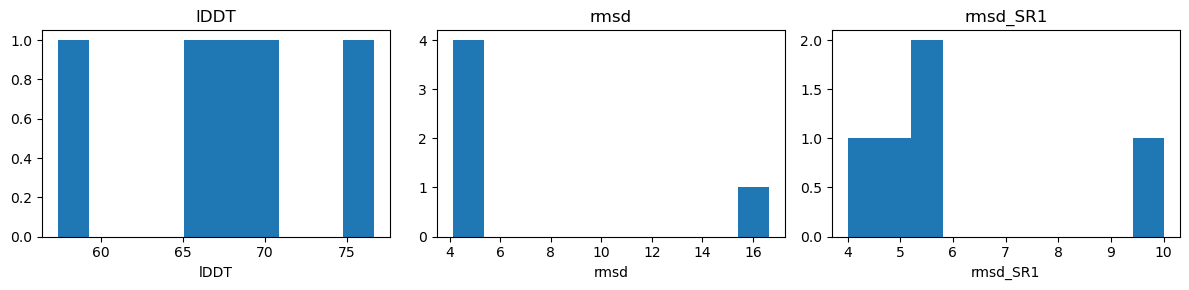

Plotting lDDT vs rmsd.


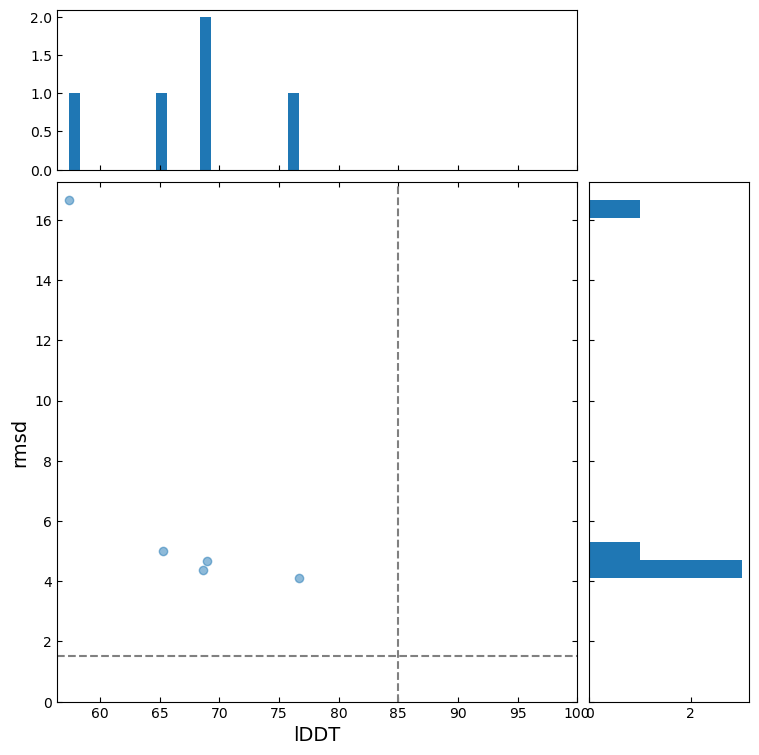

In [32]:
### Visualizing and filtering AF2 predictions
AF2_DIR = f"{WDIR}/inpainting/2_af2"

scores_af2 = pd.read_csv("scores.sc", sep="\s+", header=0)

### Filtering AF2 scores based on lddt and rmsd
# Define your desired cutoffs here:
AF2_filters = {"lDDT": [85.0, ">="],
               "rmsd": [1.5, "<="],
               "rmsd_SR1": [2.0, "<="]}  # 1st catalytic residue sc-rmsd

scores_af2_filtered = utils.filter_scores(scores_af2, AF2_filters)
utils.dump_scorefile(scores_af2_filtered, "filtered_scores.sc")

## Plotting AF2 scores
plt.figure(figsize=(12, 3))
for i,k in enumerate(AF2_filters):
    plt.subplot(1, 3, i+1)
    plt.hist(scores_af2[k])
    plt.title(k)
    plt.xlabel(k)
plt.tight_layout()
plt.show()
    
utils.plot_score_pairs(scores_af2, "lDDT", "rmsd", AF2_filters["lDDT"][0], AF2_filters["rmsd"][0])

In [ ]:
### Copying good predictions to a separate directory
os.chdir(AF2_DIR)
INPAINT_DIR = f"{WDIR}/inpainting/0_inpainting"

if len(scores_af2_filtered) > 0:
    os.makedirs("good", exist_ok=True)
    good_af2_models = [row["Output_PDB"]+".pdb" for idx,row in scores_af2_filtered.iterrows()]
    for pdb in good_af2_models:
        copy2(pdb, f"good/{pdb}")
    good_af2_models = glob.glob(f"{AF2_DIR}/good/*.pdb")
else:
    sys.exit("No good models to continue this pipeline with")

os.chdir(f"{AF2_DIR}/good")


### Aligning the ligand back into the AF2 predictions.
### This is done by aligning the AF2 model to diffusion output and copying over the ligand using PyRosetta.
### --fix_catres option will re-adjust the rotamer and tautomer of 
### any catalytic residue to be the same as in the reference model.

align_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/utils/place_ligand_after_af2.py "\
            f"--outdir with_heme --params {' '.join(params)} --fix_catres "\
            f"--pdb {' '.join(good_af2_models)} "\
            f"--ref {' '.join(glob.glob(INPAINT_DIR+'/alignment/*.pdb'))}"

p = subprocess.Popen(align_cmd, shell=True)
(output, err) = p.communicate()

## 3.1: Performing binding site design with LigandMPNN / FastRelax
<a id='ligmpnn_fr'></a>

In [ ]:
### Setting up design directory and commands
os.chdir(WDIR)
DESIGN_DIR_ligMPNN = f"{WDIR}/inpainting/3.1_design_pocket_ligandMPNN"
os.makedirs(DESIGN_DIR_ligMPNN, exist_ok=True)
os.chdir(DESIGN_DIR_ligMPNN)

AF2_DIR = f"{WDIR}/inpainting/2_af2"  # change this if you want to run it on inpainting outputs
os.makedirs(DESIGN_DIR_ligMPNN+"/logs", exist_ok=True)

### Performing 5 design iterations on each input structure
NSTRUCT = 10
cstfile = f"{SCRIPT_DIR}/theozyme/HBA/HBA_CYS_UPO.cst"

commands_design = []
cmds_filename_des = "commands_design"
with open(cmds_filename_des, "w") as file:
    for pdb in glob.glob(f"{AF2_DIR}/good/with_heme/*.pdb"):
        commands_design.append(f"{PYTHON['general']} {SCRIPT_DIR}/scripts/design/heme_pocket_ligMPNN.py "
                             f"--pdb {pdb} --nstruct {NSTRUCT} "
                             f"--scoring {SCRIPT_DIR}/scripts/design/scoring/heme_scoring.py "
                             f"--params {' '.join(params)} --cstfile {cstfile} > logs/{os.path.basename(pdb).replace('.pdb', '.log')}\n")
        file.write(commands_design[-1])

print("Example design command:")
print(commands_design[-1])


### Running design jobs with Slurm.
submit_script = "submit_design.sh"
utils.create_slurm_submit_script(filename=submit_script, name="3.1_design_pocket_ligMPNN", mem="4g", 
                                 N_cores=1, time="3:00:00", email=EMAIL, array=len(commands_design),
                                 array_commandfile=cmds_filename_des)

if not os.path.exists(DESIGN_DIR_ligMPNN+"/.done"):
    p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    (output, err) = p.communicate()

In [ ]:
DESIGN_DIR_ligMPNN = f"{WDIR}/inpainting/3.1_design_pocket_ligandMPNN"
os.chdir(DESIGN_DIR_ligMPNN)

## If you're done with design and happy with the outputs then mark it as done
if not os.path.exists(DESIGN_DIR_ligMPNN+"/.done"):
    with open(f"{DESIGN_DIR_ligMPNN}/.done", "w") as file:
        file.write(f"Run user: {username}\n")

In [ ]:
## Analyzing Rosetta designs
scores = pd.read_csv("scorefile.txt", sep="\s+", header=0)

filters = {'all_cst': [1.0, '<='],
 'nlr_SR1_rms': [0.8, '<='],
 'nlr_totrms': [1.0, '<='],
 'L_SASA': [0.2, '<='],
 'COO_hbond': [1.0, '='],
 'heme_angle_wrst': [80.0, '>='],
 'score_per_res': [0.0, '<='],
 'corrected_ddg': [-50.0, '<='],
 'cms_per_atom': [4.8, '>=']}

filtered_scores = utils.filter_scores(scores, filters)

## Plotting design scores
plt.figure(figsize=(12, 9))
for i,k in enumerate(filters):
    plt.subplot(3, 3, i+1)
    plt.hist(scores[k])
    plt.title(k)
    plt.xlabel(k)
plt.tight_layout()
plt.show()

### Copying good designs over to a new directory
if len(filtered_scores) > 0:
    os.makedirs(f"{DESIGN_DIR_ligMPNN}/good", exist_ok=True)
    for idx, row in filtered_scores.iterrows():
        copy2(row["description"]+".pdb", "good/"+row["description"]+".pdb")
else:
    print("No good designs created, bummer...")

## 4.1 Performing ligandMPNN redesign on the 2nd layer residues

Resampling residues that are not in the pocket, but also not very far from the pocket

In [ ]:
if len(glob.glob(DESIGN_DIR_ligMPNN+'/good/*.pdb')) == 0:
    sys.exit("No designs to run 2nd MPNN on.")

os.chdir(WDIR)
DESIGN_DIR_2nd_mpnn = f"{WDIR}/inpainting/4.1_2nd_mpnn"
os.makedirs(DESIGN_DIR_2nd_mpnn, exist_ok=True)
os.chdir(DESIGN_DIR_2nd_mpnn)

### Making a JSON file specifiying designable positions for each structure.
### Will also make non-pocket ALA positions as designable.
### This is to fix any surface ALA-patches that previous MPNN may have introduced.

make_json_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/design/setup_ligand_mpnn_2nd_layer.py "\
                f"--params {' '.join(params)} --ligand {LIGAND} --output_path parsed_pdbs_lig.jsonl "\
                 "--output_path masked_pos.jsonl --dist_bb 6.0 --dist_sc 5.0 "\
                f"--pdb {' '.join(glob.glob(DESIGN_DIR_ligMPNN+'/good/*.pdb'))}"

p = subprocess.Popen(make_json_cmd, shell=True)
(output, err) = p.communicate()

if not os.path.exists("masked_pos.jsonl"):
    sys.exit()

### Setting up ligandMPNN run commands
## We're doing design with 2 temperatures (more conservative than before), and 5 sequences each.

MPNN_temperatures = [0.1, 0.2]
MPNN_outputs_per_temperature = 5
MPNN_omit_AAs = "CM"

commands_mpnn = []
cmds_filename_mpnn = "commands_mpnn"
with open(cmds_filename_mpnn, "w") as file:
    for T in MPNN_temperatures:
        for f in glob.glob(DESIGN_DIR_ligMPNN+'/good/*.pdb'):
            commands_mpnn.append(f"{PYTHON['proteinMPNN']} {proteinMPNN_script} "
                                 f"--model_type ligand_mpnn --ligand_mpnn_use_atom_context 1 "
                                 "--fixed_residues_multi masked_pos.jsonl --out_folder ./ "
                                 f"--number_of_batches {MPNN_outputs_per_temperature} --temperature {T} "
                                 f"--omit_AA {MPNN_omit_AAs} --pdb_path {f} "
                                 f"--checkpoint_ligand_mpnn {SCRIPT_DIR}/lib/LigandMPNN/model_params/ligandmpnn_v_32_010_25.pt\n")
            file.write(commands_mpnn[-1])

print("Example MPNN command:")
print(commands_mpnn[-1])

### Running ligandMPNN with Slurm.
### Grouping jobs with 10 commands per one array job.

submit_script = "submit_mpnn.sh"
utils.create_slurm_submit_script(filename=submit_script, name="4.1_2nd_mpnn", mem="8g", 
                                 N_cores=1, time="0:15:00", email=EMAIL, array=len(commands_mpnn),
                                 array_commandfile=cmds_filename_mpnn, group=10)

if not os.path.exists(DESIGN_DIR_2nd_mpnn+"/.done"):
    p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    (output, err) = p.communicate()


In [ ]:
DESIGN_DIR_ligMPNN = f"{WDIR}/inpainting/3.1_design_pocket_ligandMPNN"
DESIGN_DIR_2nd_mpnn = f"{WDIR}/inpainting/4.1_2nd_mpnn"
os.chdir(DESIGN_DIR_2nd_mpnn)
if len(glob.glob(DESIGN_DIR_ligMPNN+'/good/*.pdb')) == 0:
    sys.exit("No designs to run 2nd MPNN on.")

## If you're done with design and happy with the outputs then mark it as done
if not os.path.exists(DESIGN_DIR_2nd_mpnn+"/.done"):
    with open(f"{DESIGN_DIR_2nd_mpnn}/.done", "w") as file:
        file.write(f"Run user: {username}\n")

## 5.1 AlphaFold2 predictions on the 2nd MPNN run

In [ ]:
os.chdir(WDIR)
assert os.path.exists(DESIGN_DIR_2nd_mpnn+"/.done"), "2nd MPNN has not been performed!"

AF2_DIR = f"{WDIR}/inpainting/5.1_2nd_af2"
os.makedirs(AF2_DIR, exist_ok=True)
os.chdir(AF2_DIR)

### First collecting MPNN outputs and creating FASTA files for AF2 input
mpnn_fasta = utils.parse_fasta_files(glob.glob(f"{DESIGN_DIR_2nd_mpnn}/seqs/*.fa"))
# Giving sequences unique names based on input PDB name, temperature, and sequence identifier
_mpnn_fasta = {}
for k, seq in mpnn_fasta.items():
    if "model_path" in k:
        _mpnn_fasta[k.split(",")[0]+"_native"] = seq.strip()
    else:
        _mpnn_fasta[k.split(",")[0]+"_"+k.split(",")[2].replace(" T=", "T")+"_0_"+k.split(",")[1].replace(" id=", "")] = seq.strip()
mpnn_fasta = {k:v for k,v in _mpnn_fasta.items()}

print(f"A total on {len(mpnn_fasta)} sequences will be predicted.")

## Splitting the MPNN sequences based on length
## and grouping them in smaller batches for each AF2 job
## Use group size of >40 when running on GPU. Also depends on how many sequences and resources you have.
SEQUENCES_PER_AF2_JOB = 5  # CPU
if USE_GPU_for_AF2 is True:
    SEQUENCES_PER_AF2_JOB = 100  # GPU
mpnn_fasta_split = utils.split_fasta_based_on_length(mpnn_fasta, SEQUENCES_PER_AF2_JOB, write_files=True)


In [ ]:
## Setting up AlphaFold2 run

AF2_recycles = 3
AF2_models = "4"  # add other models to this string if needed

commands_af2 = []
cmds_filename_af2 = "commands_af2"
with open(cmds_filename_af2, "w") as file:
    for ff in glob.glob("*.fasta"):
        commands_af2.append(f"{PYTHON['af2']} {AF2_script} "
                             f"--af-nrecycles {AF2_recycles} --af-models {AF2_models} "
                             f"--fasta {ff} --scorefile {ff.replace('.fasta', '.csv')}\n")
        file.write(commands_af2[-1])

print("Example AF2 command:")
print(commands_af2[-1])

### Running AF2 with Slurm.
### Running jobs on the CPU. It takes ~10 minutes per sequence

submit_script = "submit_af2.sh"
if USE_GPU_for_AF2 is True:
    utils.create_slurm_submit_script(filename=submit_script, name="5.1_2nd_af2", mem="6g", 
                                     N_cores=2, gpu=True, gres="gpu:rtx2080:1", time="00:12:00", email=EMAIL, array=len(commands_af2),
                                     array_commandfile=cmds_filename_af2)
else:
    utils.create_slurm_submit_script(filename=submit_script, name="5.1_2nd_af2", mem="6g", 
                                     N_cores=4, time="01:00:00", email=EMAIL, array=len(commands_af2),
                                     array_commandfile=cmds_filename_af2)

if not os.path.exists(AF2_DIR+"/.done"):
    p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    (output, err) = p.communicate()

In [ ]:
## If you're done with AF2 and happy with the outputs then mark it as done
AF2_DIR = f"{WDIR}/inpainting/5.1_2nd_af2"
DESIGN_DIR_ligMPNN = f"{WDIR}/inpainting/3.1_design_pocket_ligandMPNN"
os.chdir(AF2_DIR)

if not os.path.exists(AF2_DIR+"/.done"):
    with open(f"{AF2_DIR}/.done", "w") as file:
        file.write(f"Run user: {username}\n")

### Analyzing AlphaFold2 predictions

In [ ]:
# Combining all CSV scorefiles into one
os.system("head -n 1 $(ls *aa*.csv | shuf -n 1) > scores.csv ; for f in *aa*.csv ; do tail -n +2 ${f} >> scores.csv ; done")
assert os.path.exists("scores.csv"), "Could not combine scorefiles"

### Calculating the RMSDs of AF2 predictions relative to the diffusion outputs
### Catalytic residue sidechain RMSDs are calculated in the reference PDB has REMARK 666 line present

analysis_cmd = f"{PYTHON['general']} {SCRIPT_DIR}/scripts/utils/analyze_af2.py --scorefile scores.csv "\
               f"--ref_path {DESIGN_DIR_ligMPNN}/good/ --mpnn --params {' '.join(params)}"

p = subprocess.Popen(analysis_cmd, shell=True)
(output, err) = p.communicate()


In [ ]:
### Visualizing and filtering AF2 results
AF2_DIR = f"{WDIR}/inpainting/5.1_2nd_af2"
os.chdir(AF2_DIR)

scores_af2 = pd.read_csv("scores.sc", sep="\s+", header=0)

### Filtering AF2 scores based on lddt and rmsd
# Define your desired cutoffs here:
AF2_filters = {"lDDT": [85.0, ">="],
               "rmsd": [1.2, "<="],
               "rmsd_SR1": [1.0, "<="]}  # 1st catalytic residue sc-rmsd

scores_af2_filtered = utils.filter_scores(scores_af2, AF2_filters)
utils.dump_scorefile(scores_af2_filtered, "filtered_scores.sc")

## Plotting AF2 scores
plt.figure(figsize=(12, 3))
for i,k in enumerate(AF2_filters):
    plt.subplot(1, 3, i+1)
    plt.hist(scores_af2[k])
    plt.title(k)
    plt.xlabel(k)
plt.tight_layout()
plt.show()
    
utils.plot_score_pairs(scores_af2, "lDDT", "rmsd", AF2_filters["lDDT"][0], AF2_filters["rmsd"][0])

In [ ]:
### Copying good predictions to a separate directory
os.chdir(AF2_DIR)

if len(scores_af2_filtered) > 0:
    os.makedirs("good", exist_ok=True)
    good_af2_models = [row["Output_PDB"]+".pdb" for idx,row in scores_af2_filtered.iterrows()]
    for pdb in good_af2_models:
        copy2(pdb, f"good/{pdb}")
    good_af2_models = glob.glob(f"{AF2_DIR}/good/*.pdb")
else:
    sys.exit("No good models to continue this pipeline with")

os.chdir(f"{AF2_DIR}/good")


## 6.1: Final FastRelax with the ligand
Relaxing good AF2 models together with the ligand

In [ ]:
AF2_DIR = f"{WDIR}/inpainting/5.1_2nd_af2"
DESIGN_DIR_ligMPNN = f"{WDIR}/inpainting/3.1_design_pocket_ligandMPNN"
assert len(glob.glob(f"{AF2_DIR}/good/*.pdb")) > 0, "No good AF2 models to relax with"

os.chdir(WDIR)
RELAX_DIR = f"{WDIR}/inpainting/6.1_final_relax"
os.makedirs(RELAX_DIR, exist_ok=True)
os.chdir(RELAX_DIR)


## First matching up the AF2 output filenames of step 5 with pocket design filenames from step 3
ref_and_model_pairs = []
for r in glob.glob(f"{DESIGN_DIR_ligMPNN}/good/*.pdb"):
    for pdbfile in glob.glob(f"{AF2_DIR}/good/*.pdb"):
        if os.path.basename(r).replace(".pdb", "_") in pdbfile:
            ref_and_model_pairs.append((r, pdbfile))

assert len(ref_and_model_pairs) == len(glob.glob(f"{AF2_DIR}/good/*.pdb")), "Was not able to match all models with reference structures"


## Generating commands for relax jobs
### Performing 1 relax iteration on each input structure
NSTRUCT = 1
cstfile = f"{SCRIPT_DIR}/theozyme/HBA/HBA_CYS_UPO.cst"

commands_relax = []
cmds_filename_rlx = "commands_design"
with open(cmds_filename_rlx, "w") as file:
    for r_m in ref_and_model_pairs:
        commands_relax.append(f"{PYTHON['general']} {SCRIPT_DIR}/scripts/design/align_add_ligand_relax.py "
                              f"--outdir ./ --ligand {LIGAND} --ref_pdb {r_m[0]} "
                              f"--pdb {r_m[1]} --nstruct {NSTRUCT} "
                              f"--params {' '.join(params)} --cstfile {cstfile} > logs/{os.path.basename(pdb).replace('.pdb', '.log')}\n")
        file.write(commands_relax[-1])

print("Example design command:")
print(commands_design[-1])


### Running design jobs with Slurm.
submit_script = "submit_relax.sh"
utils.create_slurm_submit_script(filename=submit_script, name="6.1_final_relax", mem="4g", 
                                 N_cores=1, time="0:30:00", email=EMAIL, array=len(commands_relax),
                                 array_commandfile=cmds_filename_rlx)

if not os.path.exists(RELAX_DIR+"/.done"):
    p = subprocess.Popen(['sbatch', submit_script], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    (output, err) = p.communicate()

### Analyzing final relaxed structures
Filtering them based on the same metrics as was used for the initial design

In [ ]:
## Analyzing Rosetta designs
RELAX_DIR = f"{WDIR}/inpainting/6.1_final_relax"
os.chdir(RELAX_DIR)

scores = pd.read_csv("scorefile.txt", sep="\s+", header=0)

filters = {'all_cst': [1.0, '<='],
 'nlr_SR1_rms': [0.8, '<='],
 'nlr_totrms': [1.0, '<='],
 'L_SASA': [0.2, '<='],
 'COO_hbond': [1.0, '='],
 'heme_angle_wrst': [80.0, '>='],
 'score_per_res': [0.0, '<='],
 'corrected_ddg': [-50.0, '<='],
 'cms_per_atom': [4.8, '>='],
 'rmsd_CA_rlx_in': [1.0, "<="]}  # rmsd_CA_rlx_in is rmsd between relaxed structure and AF2 prediction

filtered_scores = utils.filter_scores(scores, filters)

## Plotting relax scores
plt.figure(figsize=(12, 9))
for i,k in enumerate(filters):
    if k not in scores.keys():
        continue
    plt.subplot(4, 3, i+1)
    plt.hist(scores[k])
    plt.title(k)
    plt.xlabel(k)
plt.tight_layout()
plt.show()

### Copying good designs over to a new directory
if len(filtered_scores) > 0:
    os.makedirs(f"{RELAX_DIR}/good", exist_ok=True)
    for idx, row in filtered_scores.iterrows():
        copy2(row["description"]+".pdb", "good/"+row["description"]+".pdb")
else:
    print("No good designs created, bummer...")

In [ ]:
if len(filtered_scores) > 0:
    print(f"CONGRATULATIONS! You have successfully designed {len(filtered_scores)} proteins against ligand {LIGAND}")
    print("You can find the design models in the directory:\n"
          f"    {RELAX_DIR}/good")
    print("\nIt is advised you manually inspect them before ordering.")